# Paper Figures — Main Paper

Publication-ready figures for the conference paper comparing FM embeddings
vs k-mer frequency features on 57 genomic classification datasets,
with orthogonal decomposition analysis.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT    = (Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd())
RESULTS = ROOT / 'results'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':         8,
    'axes.titlesize':    9,
    'axes.labelsize':    8,
    'xtick.labelsize':   7,
    'ytick.labelsize':   7,
    'legend.fontsize':   7,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'axes.grid.axis':   'y',
    'grid.alpha':       0.35,
    'grid.linewidth':   0.5,
})

FM_COLORS = {
    'NTv3':      '#2563EB',
    'HyenaDNA':  '#D97706',
    'DNABERT-2': '#059669',
    'Caduceus':  '#7C3AED',
    'Evo2':      '#DC2626',
}
KMER_COLOR = '#6B7280'

GROUP_PALETTE = {
    'EMP':               '#EF4444',
    'deep4mc':           '#F97316',
    'enhancers':         '#EAB308',
    'genomic_benchmark': '#22C55E',
    'iDHS-EL':           '#06B6D4',
    'iDNA_ABF':          '#6366F1',
    'iPro-WAEL':         '#EC4899',
    'mouse':             '#14B8A6',
    'prom':              '#A855F7',
    'splice':            '#F43F5E',
    'tf':                '#0EA5E9',
    'virus':             '#84CC16',
}
MODEL_LABELS = {
    'NTv3_650M_pre':                                        'NTv3 (650M)',
    'hyenadna-medium-160k-seqlen-hf':                       'HyenaDNA',
    'DNABERT-2-117M':                                       'DNABERT-2',
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16':       'Caduceus',
    'evo2_1b_base':                                         'Evo2 (1B)',
}
MODEL_COLOR_KEY = {
    'NTv3_650M_pre':                                        'NTv3',
    'hyenadna-medium-160k-seqlen-hf':                       'HyenaDNA',
    'DNABERT-2-117M':                                       'DNABERT-2',
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16':       'Caduceus',
    'evo2_1b_base':                                         'Evo2',
}

def task_group(name): return name.split('/')[0]
def savefig(name):
    p = FIG_DIR / name; plt.savefig(p, bbox_inches='tight'); print(f'Saved -> {p}')

print('Setup complete.')


Setup complete.


## Load data

In [2]:
rf      = pd.read_csv(RESULTS / 'classification/records_rf.csv')
dec     = pd.read_csv(RESULTS / 'decomposition/records_decomposition.csv')
fdr     = pd.read_csv(RESULTS / 'analysis/fdr_results.csv')
auc_con = pd.read_csv(RESULTS / 'analysis/auroc_consistency.csv')

rf['group']          = rf['dataset'].apply(task_group)
rf['best_kmer_MCC']  = rf[['kmer_k4_MCC','kmer_k5_MCC','kmer_k6_MCC']].max(axis=1)
rf['best_kmer_AUROC']= rf[['kmer_k4_AUROC','kmer_k5_AUROC','kmer_k6_AUROC']].max(axis=1)

print(f'RF: {rf.shape}  |  Decomp: {dec.shape}  |  FDR: {fdr.shape}')


RF: (57, 101)  |  Decomp: (57, 192)  |  FDR: (12, 12)


---
## Figure 1 — Benchmark Overview: FM vs. Best k-mer (MCC)

Head-to-head scatter for each FM model vs the best single-resolution k-mer (max of k=4,5,6).
Each point = one dataset; colour = task group; dashed diagonal = equal performance.
Points **above** the diagonal indicate FM advantage.

Saved -> /home/oem/genome-cgr-embedding/figures/fig1_benchmark_scatter.pdf


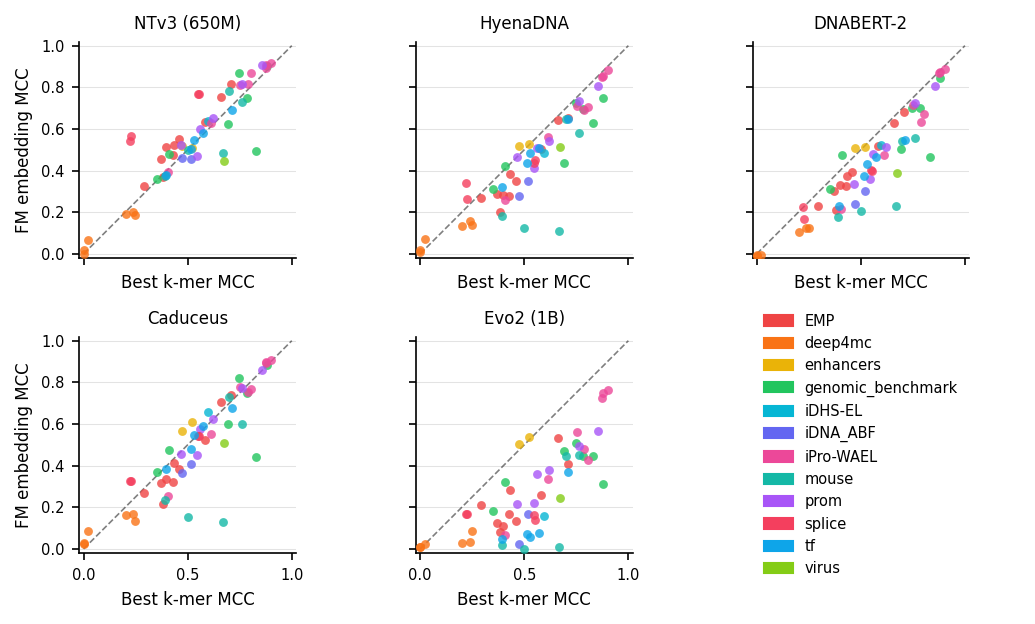

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.2), sharex=True, sharey=True)
axes = axes.flatten()

# Define FM_MODELS from MODEL_LABELS
FM_MODELS = list(MODEL_LABELS.items())

for ax, (model_key, model_label) in zip(axes[:5], FM_MODELS):
    fm_col = f'fm_{model_key}_MCC'

    if fm_col not in rf.columns:
        ax.set_title(
            model_label + '\n(no data)',
            fontsize=8,
            color='black',
            fontweight='normal'
        )
        continue

    x_all = rf['best_kmer_MCC']
    y_all = rf[fm_col].fillna(x_all)

    for grp, gdf in rf.groupby('group'):
        ax.scatter(
            gdf['best_kmer_MCC'],
            gdf[fm_col],
            color=GROUP_PALETTE.get(grp, '#999'),
            s=18,
            alpha=0.8,
            linewidths=0,
            zorder=3
        )

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, zorder=2)

    n_fm = int((y_all > x_all).sum())
    n_km = int((x_all > y_all).sum())

    ax.set_title(
        model_label,
        fontsize=8,
        color='black',
        fontweight='normal'
    )

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.set_xlabel('Best k-mer MCC')

axes[0].set_ylabel('FM embedding MCC')
axes[3].set_ylabel('FM embedding MCC')

# ---- legenda nel sesto subplot ----
legend_ax = axes[5]
legend_ax.axis('off')

handles = [
    mpatches.Patch(color=c, label=g)
    for g, c in GROUP_PALETTE.items()
    if g in rf['group'].values
]

legend_ax.legend(
    handles=handles,
    loc='center',
    fontsize=7,
    frameon=False,
    ncol=1
)

plt.tight_layout()

savefig('fig1_benchmark_scatter.pdf')
plt.show()

---
## Figure 2 — Statistical Summary: Win/Loss Counts and Effect Sizes

**(a)** Stacked horizontal bars — how many datasets FM vs k-mer wins on MCC and AUROC.  
**(b)** Median delta (FM − best k-mer) with 95% bootstrap CI.  
FDR-corrected Wilcoxon p-values annotated.

Saved -> /home/oem/genome-cgr-embedding/figures/fig2a_win_loss_mcc.pdf


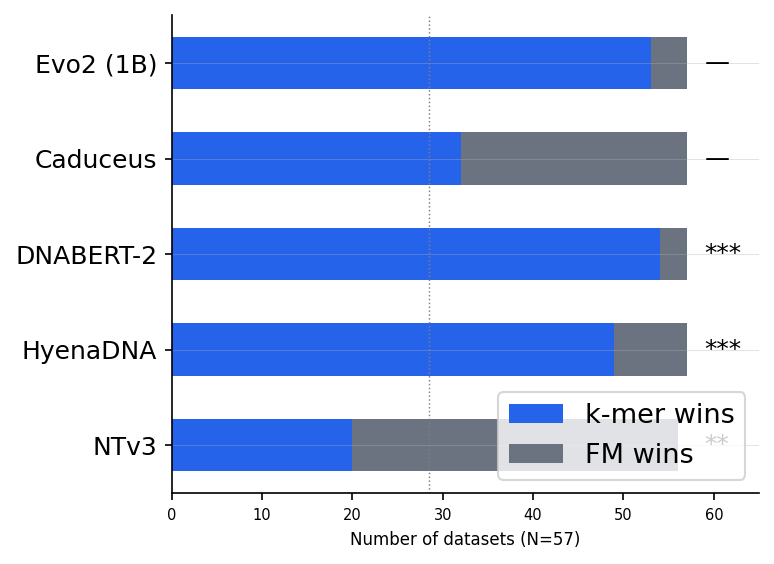

In [4]:
def bootstrap_median_ci(a, b, n=2000, seed=42):
    rng = np.random.default_rng(seed)
    deltas = (a - b).values
    boot = [np.median(rng.choice(deltas, len(deltas), replace=True)) for _ in range(n)]
    return np.percentile(boot, [2.5, 97.5])

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

target_models = {
    'NTv3_650M_pre':                                  'NTv3',
    'hyenadna-medium-160k-seqlen-hf':                  'HyenaDNA',
    'DNABERT-2-117M':                                  'DNABERT-2',
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16':  'Caduceus',
    'evo2_1b_base':                                    'Evo2 (1B)',
}

rf_fdr = fdr[fdr['probe_type'] == 'rf'].copy()

fig, ax = plt.subplots(figsize=(5.2, 3.8))


bar_data = []

for mkey, mlabel in target_models.items():

    fm_col = f'fm_{mkey}_MCC'
    km_col = 'best_kmer_MCC'

    if fm_col not in rf.columns:
        continue

    row = rf_fdr[(rf_fdr['metric'] == 'MCC') &
                 (rf_fdr['comparison'] == mkey)]

    if row.empty:
        valid = rf[[fm_col, km_col]].dropna()
        fm_w  = int((valid[fm_col] > valid[km_col]).sum())
        km_w  = int((valid[km_col] > valid[fm_col]).sum())
        sig   = '—'
    else:
        row  = row.iloc[0]
        fm_w = int(row['fm_wins'])
        km_w = int(row['kmer_wins'])
        sig  = sig_label(row['adjusted_p'])

    bar_data.append({
        'label': mlabel,
        'fm_wins': fm_w,
        'km_wins': km_w,
        'ties': 57 - fm_w - km_w,
        'sig': sig,
    })

y_pos = np.arange(len(bar_data))

fm_w = [d['fm_wins'] for d in bar_data]
km_w = [d['km_wins'] for d in bar_data]
ties = [d['ties'] for d in bar_data]
sigs = [d['sig'] for d in bar_data]

ax.barh(y_pos, km_w, color='#2563EB', height=0.55, label='k-mer wins')
ax.barh(y_pos, fm_w, left=km_w, color=KMER_COLOR, height=0.55, label='FM wins')


ax.set_yticks(y_pos)
ax.set_yticklabels([d['label'] for d in bar_data], fontsize=12)
ax.set_xlabel('Number of datasets (N=57)')
ax.set_xlim(0, 65)

for i, sig in enumerate(sigs):
    ax.text(59, i, sig, va='center', fontsize=12)

ax.axvline(57/2, color='gray', ls=':', lw=0.7)

ax.legend(fontsize=13, loc='lower right')

plt.tight_layout()
savefig('fig2a_win_loss_mcc.pdf')
plt.show()

Saved -> /home/oem/genome-cgr-embedding/figures/fig2b_effect_size_mcc.pdf


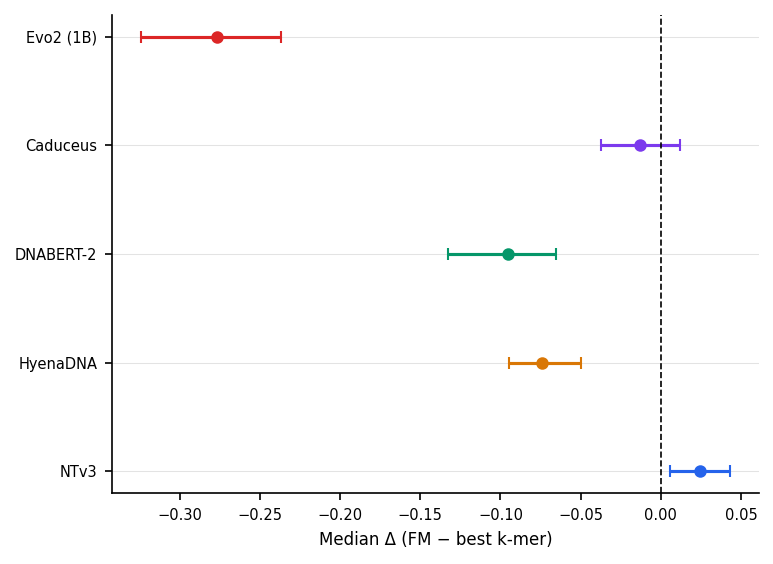

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 3.8))

model_order = list(target_models.keys())

for i, mkey in enumerate(model_order):

    fm_col = f'fm_{mkey}_MCC'
    km_col = 'best_kmer_MCC'

    if fm_col not in rf.columns:
        continue

    valid = rf[[fm_col, km_col]].dropna()
    if valid.empty:
        continue

    ci  = bootstrap_median_ci(valid[fm_col], valid[km_col])
    med = np.median((valid[fm_col] - valid[km_col]).values)

    color = FM_COLORS[MODEL_COLOR_KEY[mkey]]

    ax.errorbar(med, i,
                xerr=[[med - ci[0]], [ci[1] - med]],
                fmt='o',
                color=color,
                capsize=3,
                ms=5)

ax.axvline(0, color='black', lw=0.8, ls='--')

ax.set_yticks(np.arange(len(model_order)))
ax.set_yticklabels(list(target_models.values()))

ax.set_xlabel('Median Δ (FM − best k-mer)')

plt.tight_layout()
savefig('fig2b_effect_size_mcc.pdf')
plt.show()

---
## Figure 3 — Orthogonal Decomposition: What FM Knows Beyond k-mers

**Core contribution.** For each FM model, the embedding is decomposed as:

```
FM = ridge_proj(k-mer) + residual
```

**(a)** Ridge R² distributions — fraction of FM variance linearly predictable from k-mers (all 5 models).  
**(b)** Downstream classification performance of each component vs full FM and k-mer baseline.

In [6]:
K = 6  # use k=6 for main figure

# Models with decomposition data (now includes Evo2)
MODELS_DEC = {
    'NTv3_650M_pre':                  ('NTv3 (650M)',  FM_COLORS['NTv3']),
    'hyenadna-medium-160k-seqlen-hf': ('HyenaDNA',     FM_COLORS['HyenaDNA']),
    'DNABERT-2-117M':                 ('DNABERT-2',    FM_COLORS['DNABERT-2']),
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16': ('Caduceus', FM_COLORS['Caduceus']),
    'evo2_1b_base':                   ('Evo2 (1B)',    FM_COLORS['Evo2']),
}
# All models for RF classification panel (includes Evo2 for full FM comparison)
MODELS_ALL = {
    'NTv3_650M_pre':                  ('NTv3 (650M)',  FM_COLORS['NTv3']),
    'hyenadna-medium-160k-seqlen-hf': ('HyenaDNA',     FM_COLORS['HyenaDNA']),
    'DNABERT-2-117M':                 ('DNABERT-2',    FM_COLORS['DNABERT-2']),
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16': ('Caduceus', FM_COLORS['Caduceus']),
    'evo2_1b_base':                                    ('Evo2 (1B)', FM_COLORS['Evo2']),
}
# Models for regression (includes Evo2)
REG_MODELS = {
    'NTv3_650M_pre':              ('NTv3 (650M)',       FM_COLORS['NTv3']),
    'hyenadna-large-1m-seqlen-hf':('HyenaDNA (1M)',     FM_COLORS['HyenaDNA']),
    'DNABERT-2-117M':             ('DNABERT-2 (117M)',  FM_COLORS['DNABERT-2']),
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16': ('Caduceus', FM_COLORS['Caduceus']),
    'evo2_1b_base':               ('Evo2 (1B)', FM_COLORS['Evo2']),
}

Saved -> /home/oem/genome-cgr-embedding/figures/fig3a_r2_violin.pdf


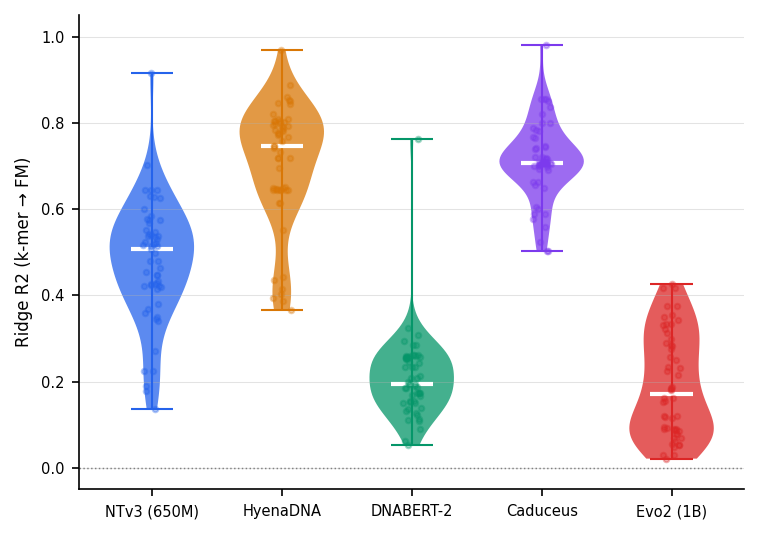

In [7]:
K = 6  # use k=6 for main figure

# ── (a) R² violin — all 5 models with decomposition ───────
fig, ax = plt.subplots(figsize=(5.1, 3.6))

r2_items = []
for mkey, (label, color) in MODELS_DEC.items():
    col = f'ridge_k{K}_{mkey}_R2'
    if col in dec.columns:
        r2_items.append((label, color, dec[col].dropna().values, True))

for i, item in enumerate(r2_items):
    label, color, vals, has_decomp = item

    parts = ax.violinplot(vals, positions=[i], showmedians=True, widths=0.65)

    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.75)

    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)

    for p in ('cbars','cmins','cmaxes'):
        parts[p].set_color(color)
        parts[p].set_linewidth(1)

    jit = np.random.default_rng(42+i).uniform(-0.07,0.07,len(vals))
    ax.scatter(np.full(len(vals), i)+jit, vals,
               color=color, alpha=0.35, s=7, zorder=3)

ax.set_xticks(range(len(r2_items)))
ax.set_xticklabels([r[0] for r in r2_items], fontsize=7)
ax.set_ylabel('Ridge R2 (k-mer → FM)')
ax.set_ylim(-0.05, 1.05)
ax.axhline(0, color='gray', ls=':', lw=0.7)

plt.tight_layout()
savefig('fig3a_r2_violin.pdf')
plt.show()

Saved -> /home/oem/genome-cgr-embedding/figures/fig3b_downstream_mcc.pdf


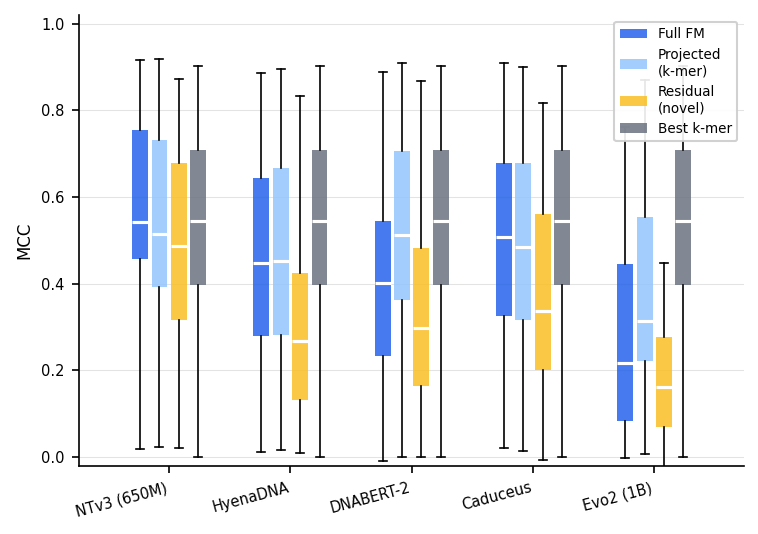

In [8]:
# ── (b) Downstream performance — all 5 models ─────────────────────────

K = 6  # Ensure K is defined for decomposition columns

fig, ax = plt.subplots(figsize=(5.1, 3.6))

labels_grp = ['Full FM', 'Projected\n(k-mer)', 'Residual\n(novel)', 'Best k-mer']
colors_grp  = ['#2563EB', '#93C5FD', '#FBBF24', KMER_COLOR]

n_models = len(MODELS_ALL)
bw = 0.16

for i, (mkey, (label, model_color)) in enumerate(MODELS_ALL.items()):

    fm_col    = f'fm_{mkey}_MCC'
    proj_col  = f'proj_k{K}_{mkey}_MCC'
    resid_col = f'resid_k{K}_{mkey}_MCC'

    has_decomp = proj_col in dec.columns and resid_col in dec.columns

    center = i * 1.0

    cols_to_plot = [fm_col, proj_col, resid_col, 'best_kmer_MCC'] if has_decomp else [fm_col, 'best_kmer_MCC']
    gc_list = [colors_grp[0], colors_grp[1], colors_grp[2], colors_grp[3]] if has_decomp else [model_color, colors_grp[3]]

    n_boxes = len(cols_to_plot)

    for j, (col, gc) in enumerate(zip(cols_to_plot, gc_list)):

        src = rf if col in rf.columns else dec
        if col not in src.columns:
            continue

        vals = src[col].dropna().values
        
        if len(vals) == 0:
            continue

        offset = (j - (n_boxes - 1) / 2) * bw
        pos = center + offset

        ax.boxplot(vals,
                   positions=[pos],
                   widths=bw*0.82,
                   patch_artist=True,
                   showfliers=False,
                   medianprops={'color':'white','linewidth':1.5},
                   whiskerprops={'linewidth':0.8},
                   capprops={'linewidth':0.8},
                   boxprops={'facecolor':gc,'alpha':0.85,'linewidth':0})

box_handles = [mpatches.Patch(facecolor=gc, label=gl, alpha=0.85)
               for gl, gc in zip(labels_grp, colors_grp)]

xtick_ctr = [i * 1.0 for i in range(n_models)]

ax.set_xticks(xtick_ctr)
ax.set_xticklabels([v[0] for v in MODELS_ALL.values()],
                   fontsize=7,
                   rotation=15,
                   ha='right')

ax.set_ylabel('MCC')
ax.set_ylim(-0.02, 1.02)

ax.legend(handles=box_handles,
          fontsize=6.5,
          loc='upper right',
          frameon=True,
          framealpha=0.9)

plt.tight_layout()
savefig('fig3b_downstream_mcc.pdf')
plt.show()

---
## Figure 4 — Per-Dataset Decomposition: R² vs. Residual Value (NTv3)

Scatter showing for each dataset (NTv3, k=6):
- **x** = Ridge R² (how much of FM embedding is k-mer explainable)  
- **y** = Residual MCC − k-mer MCC (classification value of the novel component)  
- **colour** = Full FM MCC − k-mer MCC  

Reveals when the k-mer-unexplainable residual actually improves over raw k-mer features.

Saved -> /home/oem/genome-cgr-embedding/figures/fig4_decomp_scatter.pdf


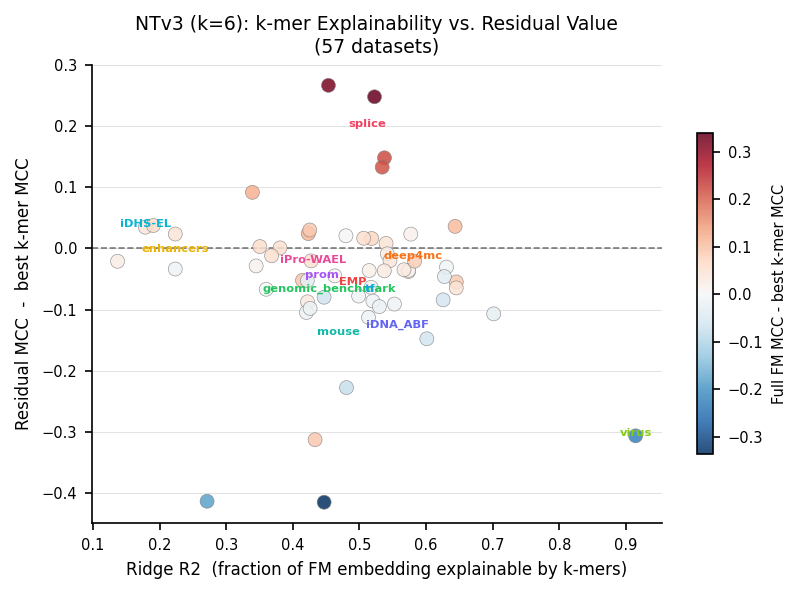

In [9]:
mkey = 'NTv3_650M_pre'
K    = 6

merged = rf[['dataset','group','best_kmer_MCC', f'fm_{mkey}_MCC']].merge(
    dec[['dataset',
         f'ridge_k{K}_{mkey}_R2',
         f'resid_k{K}_{mkey}_MCC',
         f'proj_k{K}_{mkey}_MCC']],
    on='dataset')

merged['fm_delta']    = merged[f'fm_{mkey}_MCC']          - merged['best_kmer_MCC']
merged['resid_delta'] = merged[f'resid_k{K}_{mkey}_MCC'] - merged['best_kmer_MCC']
merged['r2']          = merged[f'ridge_k{K}_{mkey}_R2']

fig, ax = plt.subplots(figsize=(5.5, 4.0))

vmin, vmax = merged['fm_delta'].min(), merged['fm_delta'].max()
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
sc = ax.scatter(merged['r2'], merged['resid_delta'],
                c=merged['fm_delta'], cmap='RdBu_r', norm=norm,
                s=45, alpha=0.85, zorder=3, linewidths=0.3, edgecolors='gray')

ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Ridge R2  (fraction of FM embedding explainable by k-mers)')
ax.set_ylabel('Residual MCC  -  best k-mer MCC')
ax.set_title('NTv3 (k=6): k-mer Explainability vs. Residual Value\n(57 datasets)',
             fontsize=9)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Full FM MCC - best k-mer MCC', fontsize=7)

for grp, gdf in merged.groupby('group'):
    cx = gdf['r2'].mean()
    cy = gdf['resid_delta'].mean()
    ax.annotate(grp, (cx, cy), fontsize=5.5, ha='center',
                color=GROUP_PALETTE.get(grp,'#555'), fontweight='bold')

plt.tight_layout()
savefig('fig4_decomp_scatter.pdf')
plt.show()


---
## Figure 5 — Decomposition Heatmap Across All Datasets (NTv3, k=6)

Three-column heatmap sorted by task group showing per-dataset:
(a) R² | (b) Residual ΔMCC vs k-mer | (c) Full FM ΔMCC vs k-mer

Saved -> /home/oem/genome-cgr-embedding/figures/fig5_decomp_heatmap.pdf


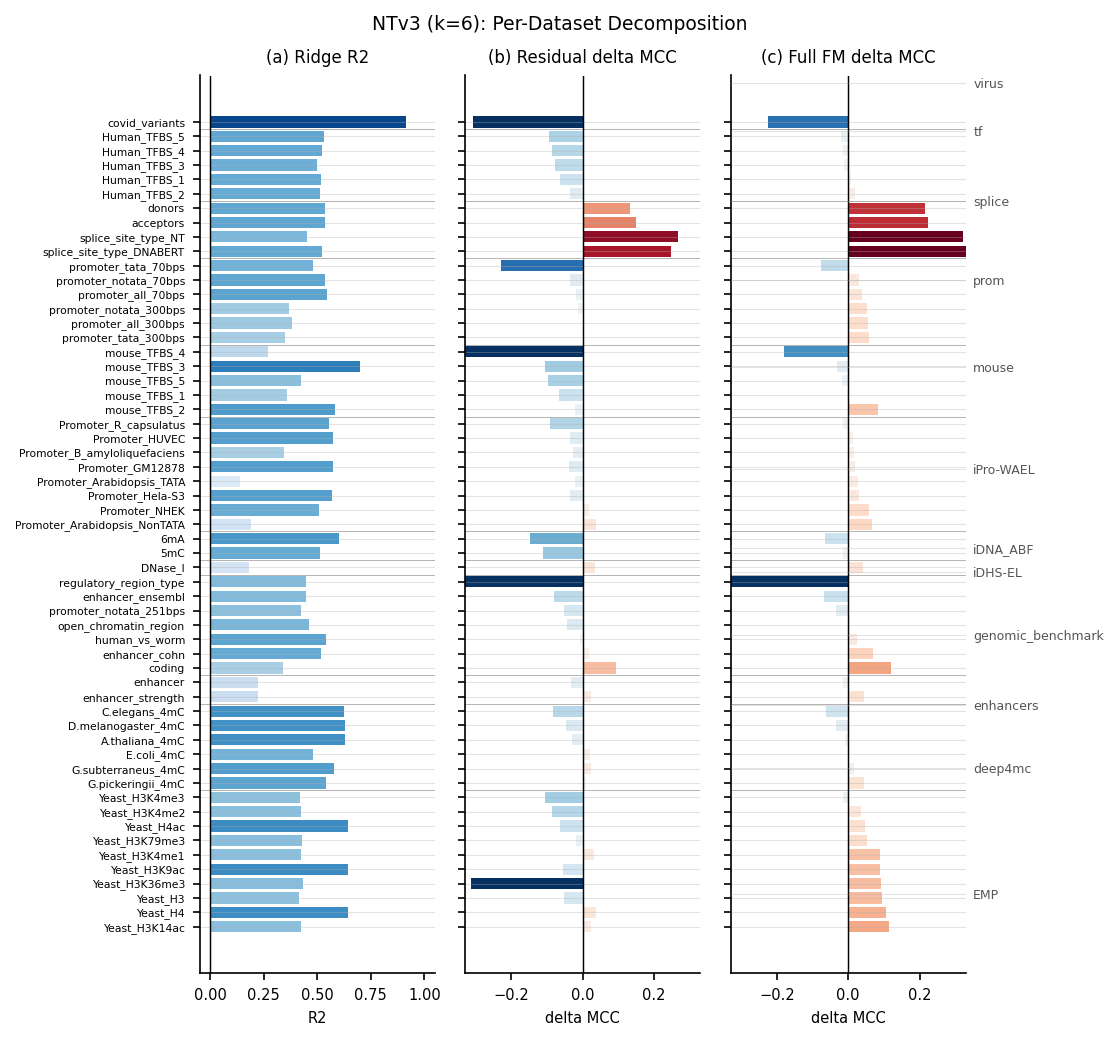

In [10]:
mkey = 'NTv3_650M_pre'; K = 6

merged = rf[['dataset','group','best_kmer_MCC', f'fm_{mkey}_MCC']].merge(
    dec[['dataset',
         f'ridge_k{K}_{mkey}_R2',
         f'resid_k{K}_{mkey}_MCC']],
    on='dataset')

merged['fm_delta']    = merged[f'fm_{mkey}_MCC']          - merged['best_kmer_MCC']
merged['resid_delta'] = merged[f'resid_k{K}_{mkey}_MCC'] - merged['best_kmer_MCC']
merged['r2']          = merged[f'ridge_k{K}_{mkey}_R2']
merged = merged.sort_values(['group','fm_delta'], ascending=[True, False])
merged['short'] = merged['dataset'].apply(lambda x: x.split('/')[-1])

fig, axes = plt.subplots(1, 3, figsize=(7.5, 7.0), sharey=True)
fig.suptitle('NTv3 (k=6): Per-Dataset Decomposition', fontsize=9)

y = np.arange(len(merged))

def draw(ax, vals, cmap_name, vmin, vmax, title, xlabel):
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    colors = mpl.colormaps[cmap_name](norm(vals))
    ax.barh(y, vals, color=colors, height=0.78, edgecolor='none')
    ax.axvline(0, color='black', lw=0.7)
    ax.set_title(title, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_xlim(vmin - 0.05*(vmax-vmin), vmax + 0.05*(vmax-vmin))
    prev = None
    for ii, grp in enumerate(merged['group']):
        if grp != prev and ii > 0:
            ax.axhline(ii - 0.5, color='black', lw=0.35, alpha=0.4)
        prev = grp

draw(axes[0], merged['r2'].values,          'Blues',   0,    1,   '(a) Ridge R2',         'R2')
draw(axes[1], merged['resid_delta'].values,  'RdBu_r', -0.3, 0.3, '(b) Residual delta MCC', 'delta MCC')
draw(axes[2], merged['fm_delta'].values,     'RdBu_r', -0.3, 0.3, '(c) Full FM delta MCC',  'delta MCC')

axes[0].set_yticks(y)
axes[0].set_yticklabels(merged['short'].tolist(), fontsize=5.2)

# Group labels on the far right
ax_twin = axes[2].twinx()
ax_twin.set_ylim(-0.5, len(merged)-0.5)
grps, starts, ends = [], [], []
prev, start = None, 0
for ii, g in enumerate(merged['group'].tolist() + [None]):
    if g != prev and prev is not None:
        grps.append(prev); starts.append(start); ends.append(ii-1)
        start = ii
    prev = g
ax_twin.set_yticks([(s+e)/2 for s,e in zip(starts,ends)])
ax_twin.set_yticklabels(grps, fontsize=6, color='#555')
ax_twin.spines[['top','right','left','bottom']].set_visible(False)
ax_twin.tick_params(length=0)

plt.tight_layout()
savefig('fig5_decomp_heatmap.pdf')
plt.show()


---
## Figure 6 — Regression Tasks: FM Embeddings vs. Best k-mer

Performance on 2 continuous-target tasks (`bulk_rna_expression`, `cage_prediction`).  
Metrics: R² and Spearman ρ. Best k-mer = max across k=4,5,6.  
Models: NTv3, HyenaDNA-large-1M, DNABERT-2, Caduceus, Evo2.

Saved -> /home/oem/genome-cgr-embedding/figures/fig6_regression.pdf


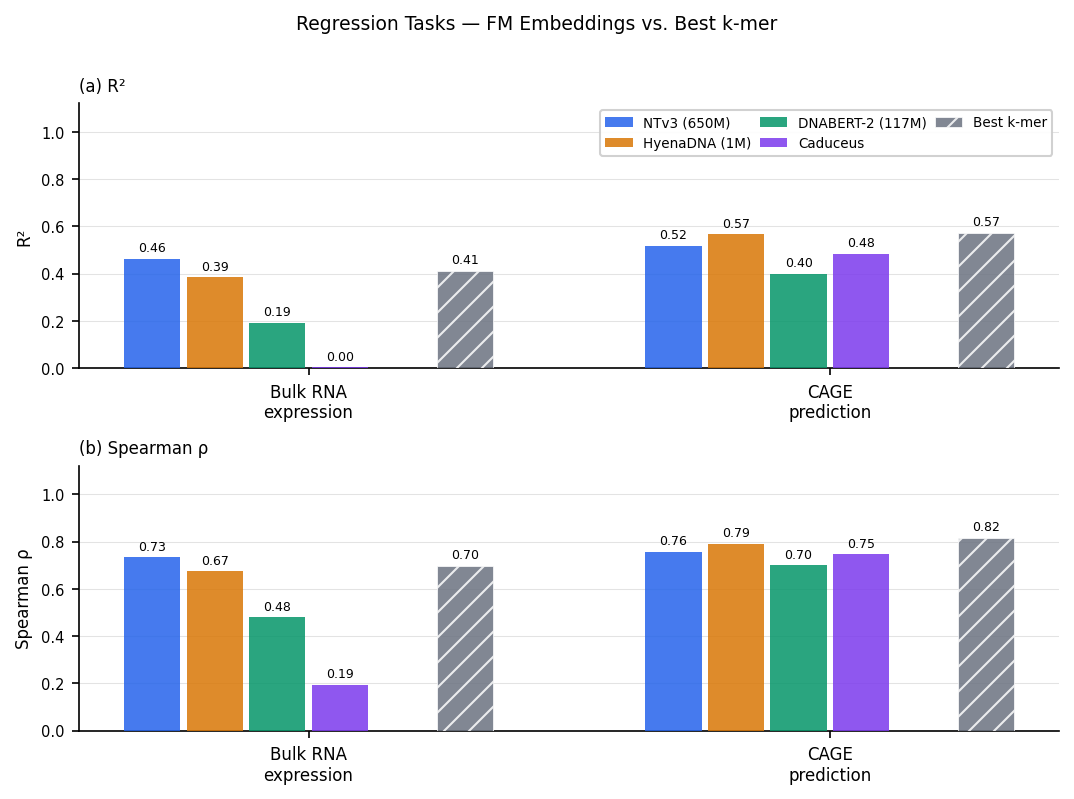

In [11]:
reg = pd.read_csv(RESULTS / 'regression_records.csv')

# Best k-mer = max across k=4,5,6 for each metric
reg['best_kmer_R2']      = reg[['kmer_k4_R2',      'kmer_k5_R2',      'kmer_k6_R2'     ]].max(axis=1)
reg['best_kmer_Spearman']= reg[['kmer_k4_Spearman', 'kmer_k5_Spearman', 'kmer_k6_Spearman']].max(axis=1)

# FM models present in the regression file
REG_MODELS = {
    'NTv3_650M_pre':              ('NTv3 (650M)',       FM_COLORS['NTv3']),
    'hyenadna-large-1m-seqlen-hf':('HyenaDNA (1M)',     FM_COLORS['HyenaDNA']),
    'DNABERT-2-117M':             ('DNABERT-2 (117M)',  FM_COLORS['DNABERT-2']),
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16': ('Caduceus', FM_COLORS['Caduceus']),
    'evo2_1b_base':               ('Evo2 (1B)', FM_COLORS['Evo2']),
}

# Keep only rows that have at least one regression metric
reg_only = reg[reg['best_kmer_R2'].notna()].copy()  # Only LRA regression tasks
datasets  = reg_only['dataset'].tolist()
TASK_LABELS = {
    'bulk_rna_expression': 'Bulk RNA\nexpression',
    'cage_prediction':     'CAGE\nprediction',
}

METRICS = [
    ('R2',      'R²',       (0.0, 1.0)),
    ('Spearman','Spearman ρ',(0.0, 1.0)),
]

n_met = len(METRICS)
n_ds  = len(datasets)
fig, axes = plt.subplots(n_met, 1, figsize=(7.2, 5.2))
fig.suptitle('Regression Tasks — FM Embeddings vs. Best k-mer', fontsize=9, y=1.01)

x     = np.arange(n_ds)
n_grp = len(REG_MODELS) + 1          # FM models + k-mer baseline
bw    = 0.72 / n_grp

for ax, (met_key, met_label, (ylo, yhi)) in zip(axes, METRICS):
    kmer_col = f'best_kmer_{met_key}'

    for j, (mkey, (mlabel, mcolor)) in enumerate(REG_MODELS.items()):
        fm_col = f'fm_{mkey}_{met_key}'
        if fm_col not in reg_only.columns:
            continue
        vals = [reg_only.loc[reg_only['dataset'] == ds, fm_col].values[0]
                if ds in reg_only['dataset'].values else np.nan
                for ds in datasets]
        offset = (j - (n_grp - 1) / 2) * bw
        bars = ax.bar(x + offset, vals, width=bw * 0.9,
                      color=mcolor, alpha=0.85, label=mlabel, zorder=3)

    # k-mer baseline (rightmost bar in each group)
    kvals = [reg_only.loc[reg_only['dataset'] == ds, kmer_col].values[0]
             if ds in reg_only['dataset'].values else np.nan
             for ds in datasets]
    offset = ((n_grp - 1) - (n_grp - 1) / 2) * bw
    ax.bar(x + offset, kvals, width=bw * 0.9,
           color=KMER_COLOR, alpha=0.85, label='Best k-mer', zorder=3,
           hatch='//', edgecolor='white', linewidth=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels([TASK_LABELS.get(d, d) for d in datasets], fontsize=8)
    ax.set_ylabel(met_label, fontsize=8)
    ax.set_ylim(ylo, yhi * 1.12)
    ax.set_title(f'({chr(97 + METRICS.index((met_key, met_label, (ylo, yhi))))}) {met_label}',
                 fontsize=8, loc='left')
    ax.grid(axis='y', alpha=0.35, linewidth=0.5)
    ax.set_axisbelow(True)

    # Annotate bar values
    for patch_collection in ax.containers:
        ax.bar_label(patch_collection, fmt='%.2f', fontsize=6,
                     padding=2, label_type='edge')

axes[0].legend(fontsize=6.5, loc='upper right', frameon=True, framealpha=0.9,
               ncol=3, columnspacing=0.6)

plt.tight_layout()
savefig('fig6_regression.pdf')
plt.show()

Saved -> /home/oem/genome-cgr-embedding/figures/fig6a_regression_R2.pdf


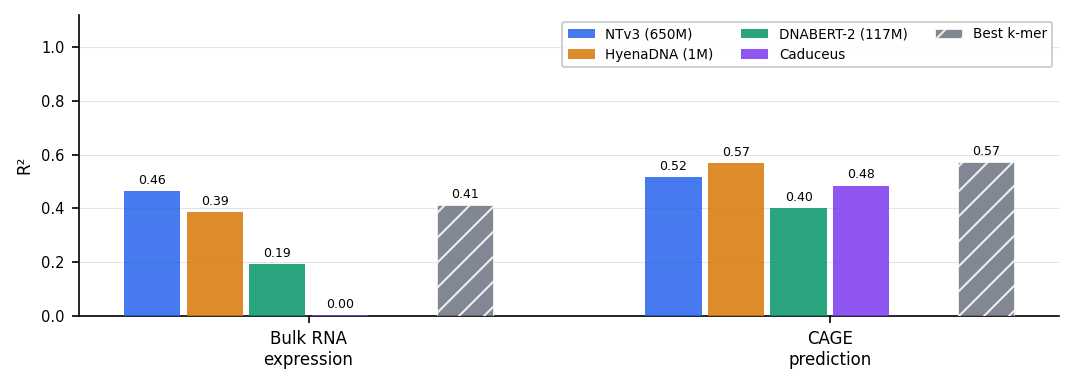

In [12]:
reg = pd.read_csv(RESULTS / 'regression_records.csv')

reg['best_kmer_R2'] = reg[['kmer_k4_R2','kmer_k5_R2','kmer_k6_R2']].max(axis=1)
reg['best_kmer_Spearman'] = reg[['kmer_k4_Spearman','kmer_k5_Spearman','kmer_k6_Spearman']].max(axis=1)

reg_only = reg[reg['best_kmer_R2'].notna()].copy()
datasets = reg_only['dataset'].tolist()

TASK_LABELS = {
    'bulk_rna_expression': 'Bulk RNA\nexpression',
    'cage_prediction': 'CAGE\nprediction',
}

fig, ax = plt.subplots(figsize=(7.2, 2.6))

x = np.arange(len(datasets))
n_grp = len(REG_MODELS) + 1
bw = 0.72 / n_grp

met_key = 'R2'
met_label = 'R²'
ylo, yhi = (0.0,1.0)

kmer_col = f'best_kmer_{met_key}'

for j,(mkey,(mlabel,mcolor)) in enumerate(REG_MODELS.items()):

    fm_col = f'fm_{mkey}_{met_key}'
    if fm_col not in reg_only.columns:
        continue

    vals = []

    for ds in datasets:
        if ds in reg_only['dataset'].values and fm_col in reg_only.columns:
            v = reg_only.loc[reg_only['dataset'] == ds, fm_col]
            vals.append(v.values[0] if not v.empty else np.nan)
        else:
            vals.append(np.nan)

    offset = (j-(n_grp-1)/2)*bw

    ax.bar(
        x+offset,
        vals,
        width=bw*0.9,
        color=mcolor,
        alpha=0.85,
        label=mlabel,
        zorder=3
    )

kvals = [
    reg_only.loc[reg_only['dataset']==ds,kmer_col].values[0]
    if ds in reg_only['dataset'].values else np.nan
    for ds in datasets
]

offset=((n_grp-1)-(n_grp-1)/2)*bw

ax.bar(
    x+offset,
    kvals,
    width=bw*0.9,
    color=KMER_COLOR,
    alpha=0.85,
    label='Best k-mer',
    zorder=3,
    hatch='//',
    edgecolor='white',
    linewidth=0.4
)

ax.set_xticks(x)
ax.set_xticklabels([TASK_LABELS.get(d,d) for d in datasets],fontsize=8)

ax.set_ylabel(met_label,fontsize=8)
ax.set_ylim(ylo,yhi*1.12)

ax.grid(axis='y',alpha=0.35,linewidth=0.5)
ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(container,fmt='%.2f',fontsize=6,padding=2)

ax.legend(fontsize=6.5,loc='upper right',frameon=True,framealpha=0.9,ncol=3)

plt.tight_layout()
savefig('fig6a_regression_R2.pdf')
plt.show()

Saved -> /home/oem/genome-cgr-embedding/figures/fig_regression_R2.pdf


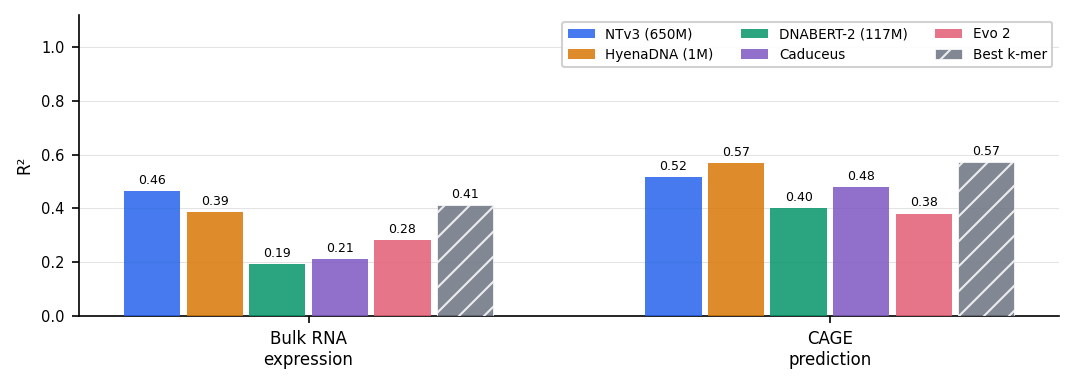

In [13]:
reg = pd.read_csv(RESULTS / 'regression_records.csv')
reg['best_kmer_R2'] = reg[['kmer_k4_R2', 'kmer_k5_R2', 'kmer_k6_R2']].max(axis=1)
reg['best_kmer_Spearman'] = reg[['kmer_k4_Spearman',
                                  'kmer_k5_Spearman',
                                  'kmer_k6_Spearman']].max(axis=1)
reg_only = reg[reg['best_kmer_R2'].notna()].copy()
datasets  = reg_only['dataset'].tolist()

TASK_LABELS = {
    'bulk_rna_expression': 'Bulk RNA\nexpression',
    'cage_prediction':     'CAGE\nprediction',
}

MANUAL_VALS = {
    'caduceus_manual': {
        'bulk_rna_expression': 0.21,
        'cage_prediction':     0.48,
    },
    'evo2_manual': {
        'bulk_rna_expression': 0.28,
        'cage_prediction':     0.38,
    },
}

EXCLUDE = {
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16',
    'evo2_1b_base',
}

all_models = {k: v for k, v in REG_MODELS.items() if k not in EXCLUDE}
all_models['caduceus_manual'] = ('Caduceus', '#7E57C2')
all_models['evo2_manual']     = ('Evo 2',    '#E35D75')

met_key   = 'R2'
met_label = 'R²'
kmer_col  = f'best_kmer_{met_key}'

n_grp = len(all_models) + 1
bw    = 0.72 / n_grp

fig, ax = plt.subplots(figsize=(7.2, 2.6))
x = np.arange(len(datasets))

for j, (mkey, (mlabel, mcolor)) in enumerate(all_models.items()):

    if mkey in MANUAL_VALS:
        vals = [MANUAL_VALS[mkey].get(ds, np.nan) for ds in datasets]
    else:
        fm_col = f'fm_{mkey}_{met_key}'
        if fm_col not in reg_only.columns:
            vals = [np.nan] * len(datasets)
        else:
            vals = [
                reg_only.loc[reg_only['dataset'] == ds, fm_col].values[0]
                if ds in reg_only['dataset'].values else np.nan
                for ds in datasets
            ]

    offset = (j - (n_grp - 1) / 2) * bw
    ax.bar(x + offset, vals,
           width=bw * 0.9, color=mcolor, alpha=0.85,
           label=mlabel, zorder=3)

# Barra k-mer
kvals = [
    reg_only.loc[reg_only['dataset'] == ds, kmer_col].values[0]
    if ds in reg_only['dataset'].values else np.nan
    for ds in datasets
]
offset = ((n_grp - 1) - (n_grp - 1) / 2) * bw
ax.bar(x + offset, kvals,
       width=bw * 0.9, color=KMER_COLOR, alpha=0.85,
       label='Best k-mer', zorder=3,
       hatch='//', edgecolor='white', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels([TASK_LABELS.get(d, d) for d in datasets], fontsize=8)
ax.set_ylabel(met_label, fontsize=8)
ax.set_ylim(0.0, 1.12)
ax.grid(axis='y', alpha=0.35, linewidth=0.5)
ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=6, padding=2)

ax.legend(fontsize=6.5, loc='upper right',
          frameon=True, framealpha=0.9, ncol=3)
plt.tight_layout()
savefig('fig_regression_R2.pdf')
plt.show()

In [14]:
print(list(REG_MODELS.keys()))

['NTv3_650M_pre', 'hyenadna-large-1m-seqlen-hf', 'DNABERT-2-117M', 'caduceus-ph_seqlen-131k_d_model-256_n_layer-16', 'evo2_1b_base']


---
## Figure S — RF vs Linear Probe: scatter per FM model

Same layout as Fig. 1. Each panel compares **RF MCC** (x-axis) vs **LP MCC** (y-axis) 
for one FM model. Panel 6 shows the k-mer baseline (best k ∈ {4,5,6}).  
Points **above** the diagonal: LP wins; **below**: RF wins.

### RF vs LP — Summary statistics

For each model: N datasets, LP > RF wins (margin > 0.01), RF > LP wins (margin > 0.01), mean/median Δ (LP − RF MCC), and two-sided Wilcoxon signed-rank p-value.

In [ ]:
# ── RF vs LP summary statistics table ────────────────────────────────────────
from scipy import stats as _stats

lp = pd.read_csv(RESULTS / 'classification/records_linear_probe.csv')
rf_lp = rf.merge(lp, on='dataset', suffixes=('', '_lp'))
rf_lp['lp_best_kmer_MCC'] = rf_lp[['lp_kmer_k4_MCC', 'lp_kmer_k5_MCC', 'lp_kmer_k6_MCC']].max(axis=1)

_LP_COLS = {
    'NTv3 (650M)':  ('fm_NTv3_650M_pre_MCC',
                     'lp_fm_NTv3_650M_pre_MCC__pool_max'),
    'HyenaDNA':     ('fm_hyenadna-medium-160k-seqlen-hf_MCC',
                     'lp_fm_hyenadna-medium-160k-seqlen-hf_MCC__pool_max'),
    'DNABERT-2':    ('fm_DNABERT-2-117M_MCC',
                     'lp_fm_DNABERT-2-117M_MCC__pool_max'),
    'Caduceus':     ('fm_caduceus-ph_seqlen-131k_d_model-256_n_layer-16_MCC',
                     'lp_fm_caduceus-ph_seqlen-131k_d_model-256_n_layer-16_MCC'),
    'Evo2 (1B)':    ('fm_evo2_1b_base_MCC',
                     'lp_fm_evo2_1b_base_MCC'),
    'Best k-mer':   ('best_kmer_MCC',
                     'lp_best_kmer_MCC'),
}

def _sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

rows = []
for label, (rc, lc) in _LP_COLS.items():
    v = rf_lp[[rc, lc]].dropna()
    d = v[lc] - v[rc]
    _, p = _stats.wilcoxon(d)
    rows.append({
        'Model':              label,
        'N':                  len(d),
        'LP > RF (Δ>0.01)':   int((d >  0.01).sum()),
        'RF > LP (Δ>0.01)':   int((d < -0.01).sum()),
        'Mean Δ (LP−RF)':     round(d.mean(),   4),
        'Median Δ (LP−RF)':   round(d.median(), 4),
        'p-value (Wilcoxon)': round(p, 4),
        'Sig.':               _sig(p),
    })

df_stats = pd.DataFrame(rows).set_index('Model')
display(df_stats)


Saved -> /home/oem/genome-cgr-embedding/figures/sup_s1_rf_vs_lp.pdf


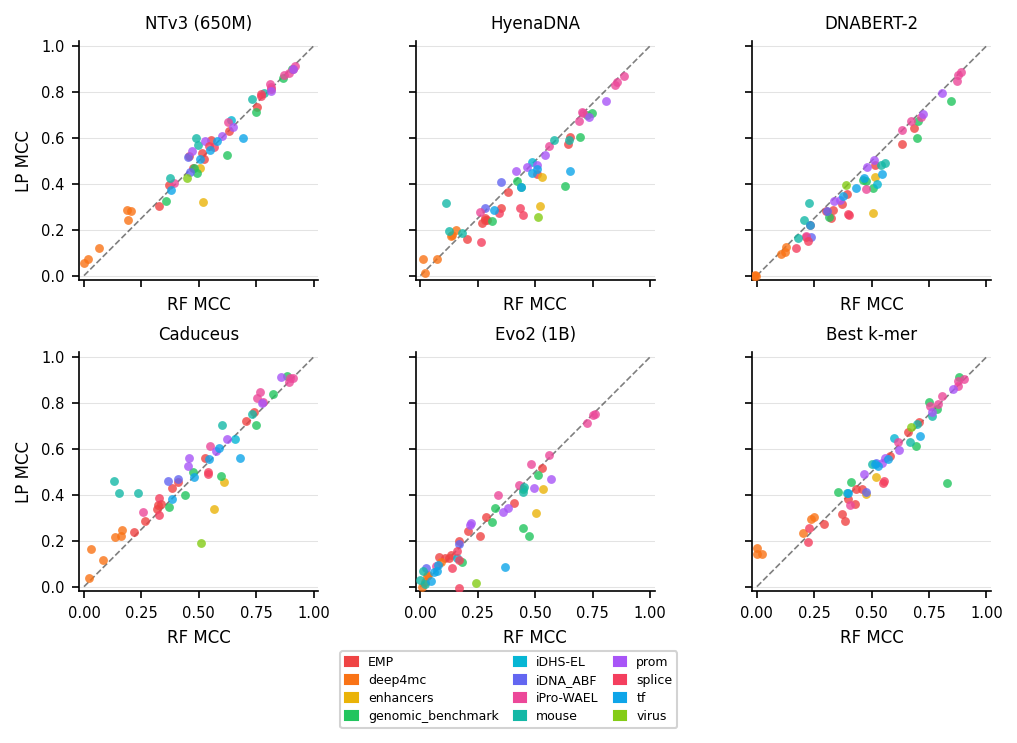

In [16]:
# ── RF vs LP per-model scatter (Fig. 1 style) ────────────────────────────────
lp = pd.read_csv(RESULTS / 'classification/records_linear_probe.csv')
lp['group'] = lp['dataset'].apply(task_group)

# Best LP column per model: prefer __pool_max when available, else bare column
LP_COLS = {
    'NTv3_650M_pre':                                  'lp_fm_NTv3_650M_pre_MCC__pool_max',
    'hyenadna-medium-160k-seqlen-hf':                 'lp_fm_hyenadna-medium-160k-seqlen-hf_MCC__pool_max',
    'DNABERT-2-117M':                                 'lp_fm_DNABERT-2-117M_MCC__pool_max',
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16': 'lp_fm_caduceus-ph_seqlen-131k_d_model-256_n_layer-16_MCC',
    'evo2_1b_base':                                   'lp_fm_evo2_1b_base_MCC',
}

# Merge RF and LP on dataset
merged_rlp = rf.merge(lp, on='dataset', suffixes=('', '_lp'))
merged_rlp['lp_best_kmer_MCC'] = merged_rlp[
    ['lp_kmer_k4_MCC', 'lp_kmer_k5_MCC', 'lp_kmer_k6_MCC']
].max(axis=1)

FM_MODELS_5 = list(MODEL_LABELS.items())  # 5 FM models

fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (mkey, mlabel) in zip(axes[:5], FM_MODELS_5):
    rf_col = f'fm_{mkey}_MCC'
    lp_col = LP_COLS.get(mkey)

    if rf_col not in merged_rlp.columns or lp_col not in merged_rlp.columns:
        ax.set_title(
            mlabel + '\n(no data)',
            fontsize=8,
            color='black',
            fontweight='normal'
        )
        continue

    valid = merged_rlp[[rf_col, lp_col, 'group']].dropna()

    for grp, gdf in valid.groupby('group'):
        ax.scatter(
            gdf[rf_col],
            gdf[lp_col],
            color=GROUP_PALETTE.get(grp, '#999'),
            s=18,
            alpha=0.8,
            linewidths=0,
            zorder=3
        )

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, zorder=2)

    ax.set_title(
        mlabel,
        fontsize=8,
        color='black',
        fontweight='normal'
    )

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.set_xlabel('RF MCC')

axes[0].set_ylabel('LP MCC')
axes[3].set_ylabel('LP MCC')

# Panel 6: k-mer RF vs k-mer LP
ax6 = axes[5]

valid6 = merged_rlp[
    ['best_kmer_MCC', 'lp_best_kmer_MCC', 'group']
].dropna()

for grp, gdf in valid6.groupby('group'):
    ax6.scatter(
        gdf['best_kmer_MCC'],
        gdf['lp_best_kmer_MCC'],
        color=GROUP_PALETTE.get(grp, '#999'),
        s=18,
        alpha=0.8,
        linewidths=0,
        zorder=3
    )

ax6.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, zorder=2)

ax6.set_title(
    'Best k-mer',
    fontsize=8,
    color='black',
    fontweight='normal'
)

ax6.set_xlim(-0.02, 1.02)
ax6.set_ylim(-0.02, 1.02)
ax6.set_aspect('equal')
ax6.set_xlabel('RF MCC')

# Shared legend at bottom, horizontal on two rows
handles = [
    mpatches.Patch(color=c, label=g)
    for g, c in GROUP_PALETTE.items()
    if g in merged_rlp['group'].values
]

fig.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=6,
    frameon=True,
    framealpha=0.85,
    handlelength=1.0,
    columnspacing=1.2,
    labelspacing=0.4
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

savefig('sup_s1_rf_vs_lp.pdf')
plt.show()